<a href="https://colab.research.google.com/github/tanishataranoon/MY_ML_project/blob/main/Toxic_Text_Classification_Comparison_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud transformers torch --quiet

In [ ]:
import pandas as pd
import tensorflow as tf
import numpy as np

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (12, 5)

In [ ]:
from wordcloud import WordCloud
from nltk.corpus import stopwords

In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [ ]:
import string
nltk.download('omw-1.4')

sns.set_theme(style='whitegrid')

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
import re
from collections import Counter

# Load dataset
from https://huggingface.co/datasets/thesofakillers/jigsaw-toxic-comment-classification-challenge?library=datasets


In [ ]:
from datasets import load_dataset

df = load_dataset("thesofakillers/jigsaw-toxic-comment-classification-challenge")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/68.8M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/60.4M [00:00<?, ?B/s]

test_labels.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/159571 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/306328 [00:00<?, ? examples/s]

In [ ]:
df

DatasetDict({
    train: Dataset({
        features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 159571
    })
    test: Dataset({
        features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 306328
    })
})

In [ ]:
train_df = df['train'].to_pandas()
test_df = df['test'].to_pandas()

Train data size and trained data

In [ ]:
print(train_df.shape)
print(train_df.head())

(159571, 8)
                 id                                       comment_text  toxic  \
0  0000997932d777bf  Explanation\nWhy the edits made under my usern...      0   
1  000103f0d9cfb60f  D'aww! He matches this background colour I'm s...      0   
2  000113f07ec002fd  Hey man, I'm really not trying to edit war. It...      0   
3  0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...      0   
4  0001d958c54c6e35  You, sir, are my hero. Any chance you remember...      0   

   severe_toxic  obscene  threat  insult  identity_hate  
0             0        0       0       0              0  
1             0        0       0       0              0  
2             0        0       0       0              0  
3             0        0       0       0              0  
4             0        0       0       0              0  


In [ ]:
print('Columns: ', train_df.columns.tolist())

Columns:  ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


In [ ]:
print('\nData Types: \n', train_df.dtypes)


Data Types: 
 id               object
comment_text     object
toxic             int64
severe_toxic      int64
obscene           int64
threat            int64
insult            int64
identity_hate     int64
dtype: object


In [ ]:
print('\nMissing values:\n', train_df.isnull().sum())


Missing values:
 id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


Test data size and test data

In [ ]:
print(test_df.shape)
print(test_df.head())

(306328, 8)
                 id                                       comment_text  toxic  \
0  00001cee341fdb12  Yo bitch Ja Rule is more succesful then you'll...    NaN   
1  0000247867823ef7  == From RfC == \n\n The title is fine as it is...    NaN   
2  00013b17ad220c46  " \n\n == Sources == \n\n * Zawe Ashton on Lap...    NaN   
3  00017563c3f7919a  :If you have a look back at the source, the in...    NaN   
4  00017695ad8997eb          I don't anonymously edit articles at all.    NaN   

   severe_toxic  obscene  threat  insult  identity_hate  
0           NaN      NaN     NaN     NaN            NaN  
1           NaN      NaN     NaN     NaN            NaN  
2           NaN      NaN     NaN     NaN            NaN  
3           NaN      NaN     NaN     NaN            NaN  
4           NaN      NaN     NaN     NaN            NaN  


**Binary 'any_toxic' column **




In [ ]:
label_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
train_df['any_toxic'] = train_df[label_cols].max(axis=1)


print(f'Total comments    : {len(train_df):,}')
print(f'Toxic comments    : {train_df["any_toxic"].sum():,} ({train_df["any_toxic"].mean()*100:.1f}%)')
print(f'Non-toxic comments: {(train_df["any_toxic"]==0).sum():,} ({(train_df["any_toxic"]==0).mean()*100:.1f}%)')

Total comments    : 159,571
Toxic comments    : 16,225 (10.2%)
Non-toxic comments: 143,346 (89.8%)


In [ ]:
# print(f'Total comments : {len(df):,}')
# print(f'Total toxic comments : {len(train_df[train_df.any_toxic == 1]):,}')
# print(f'Total non-toxic comments : {len(train_df[train_df.any_toxic == 0]):,}')

# Exploratory Data Analysis (EDA)

In [ ]:
label_counts = train_df[label_cols].sum().sort_values(ascending=False)
print(label_counts)

toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478
dtype: int64


Bar Chart of Number of Comments per Toxicity Label \
A pie chart for non-toxic vs toxic

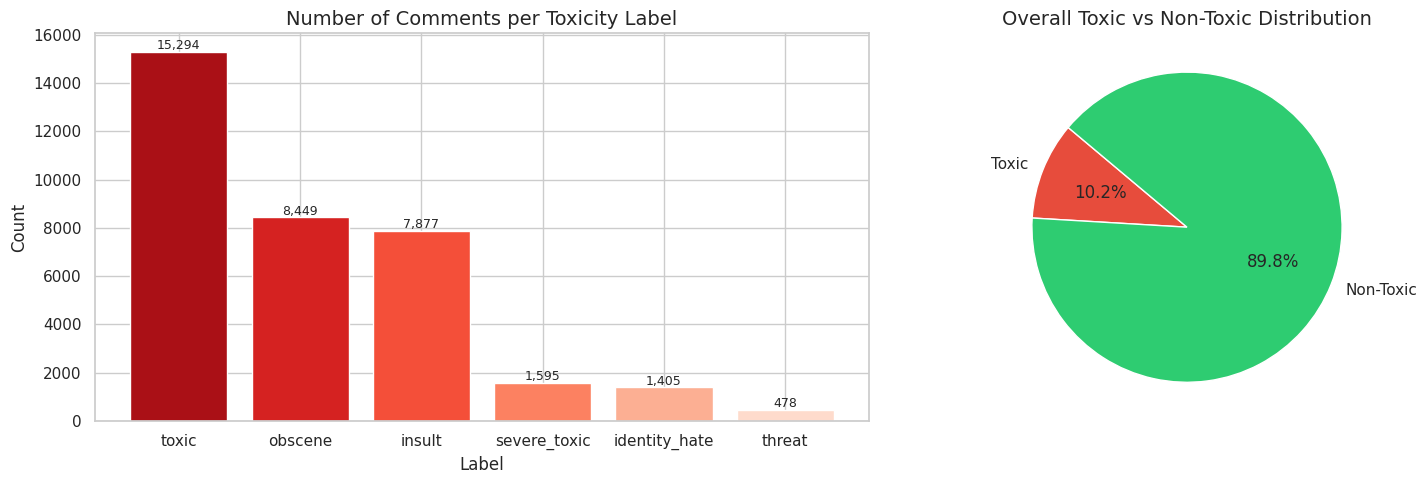

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(label_counts.index, label_counts.values, color=sns.color_palette('Reds_r', len(label_cols)))
axes[0].set_title('Number of Comments per Toxicity Label', fontsize=14)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

axes[1].pie(
    [train_df['any_toxic'].sum(), (train_df['any_toxic']==0).sum()],
    labels=['Toxic', 'Non-Toxic'],
    autopct='%1.1f%%',
    colors=['#e74c3c', '#2ecc71'],
    startangle=140
)
axes[1].set_title('Overall Toxic vs Non-Toxic Distribution', fontsize=14)

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()



In [ ]:
co_matrix = train_df[label_cols].T.dot(train_df[label_cols])
co_matrix

,toxic,severe_toxic,obscene,threat,insult,identity_hate
toxic,15294,1595,7926,449,7344,1302
severe_toxic,1595,1595,1517,112,1371,313
obscene,7926,1517,8449,301,6155,1032
threat,449,112,301,478,307,98
insult,7344,1371,6155,307,7877,1160
identity_hate,1302,313,1032,98,1160,1405


Multi-label Co-occurrence Heatmap a comment can belong to multiple categories at the same time

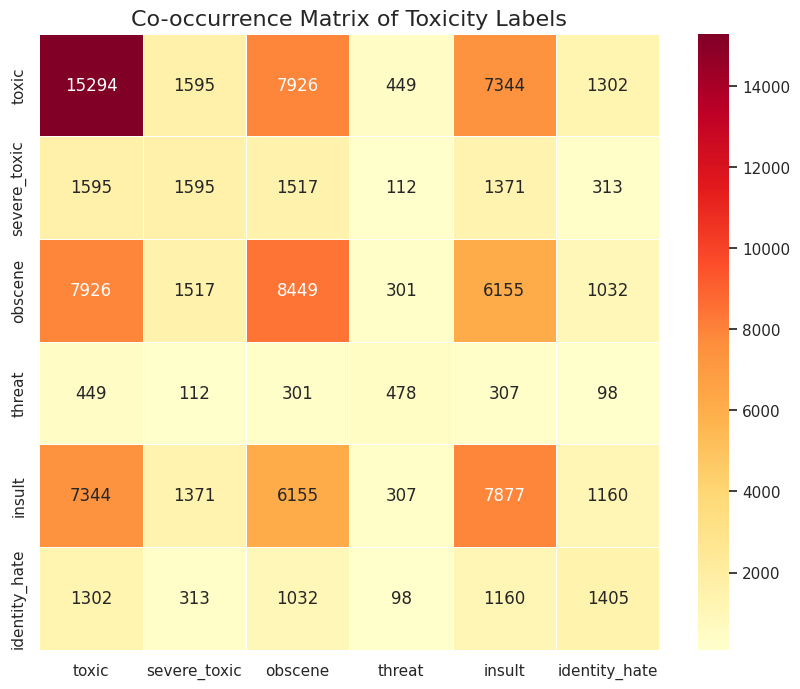

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(co_matrix, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Co-occurrence Matrix of Toxicity Labels', fontsize=16)
plt.savefig('co_occurrence_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


Word Cloud

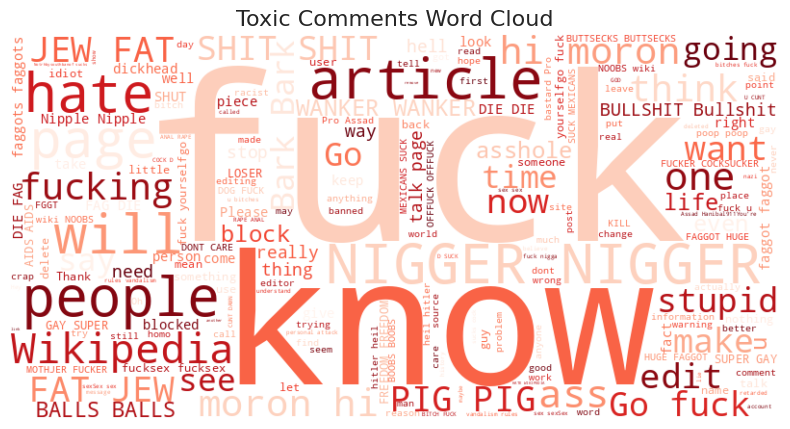

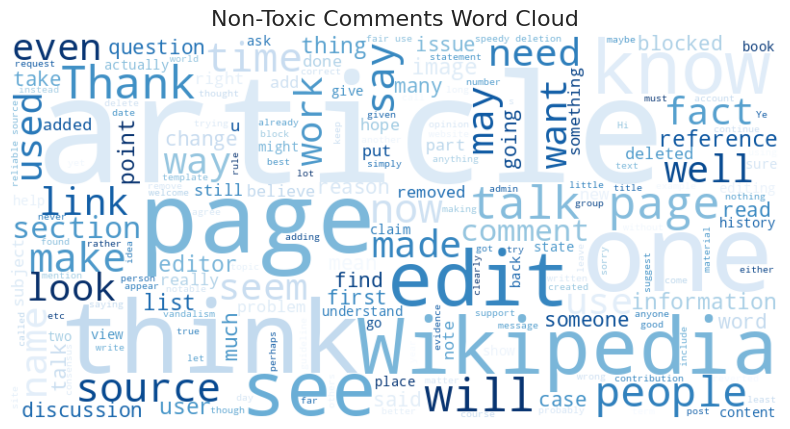

In [ ]:
def generate_wordcloud(text_data, title, colormap='Reds'):
  text=' '.join(text_data)
  wordcloud = WordCloud(
      width=800,
      height=400,
      background_color='white',
      colormap=colormap,
      max_words=200,
    ).generate(text)
  plt.figure(figsize=(10, 5))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.title(title, fontsize=16)
  plt.axis('off')
  plt.show()

generate_wordcloud(train_df[train_df['any_toxic'] == 1]['comment_text'], 'Toxic Comments Word Cloud','Reds')
generate_wordcloud(train_df[train_df['any_toxic'] == 0]['comment_text'], 'Non-Toxic Comments Word Cloud', 'Blues')

Most frequent words and phrases in toxic comments.
*   Unigrams → single words
*   Bigrams → two-word combinations

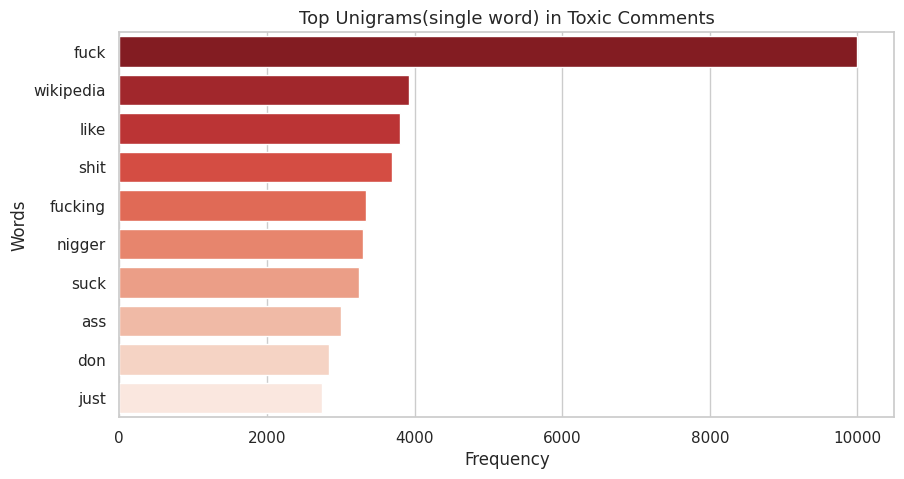

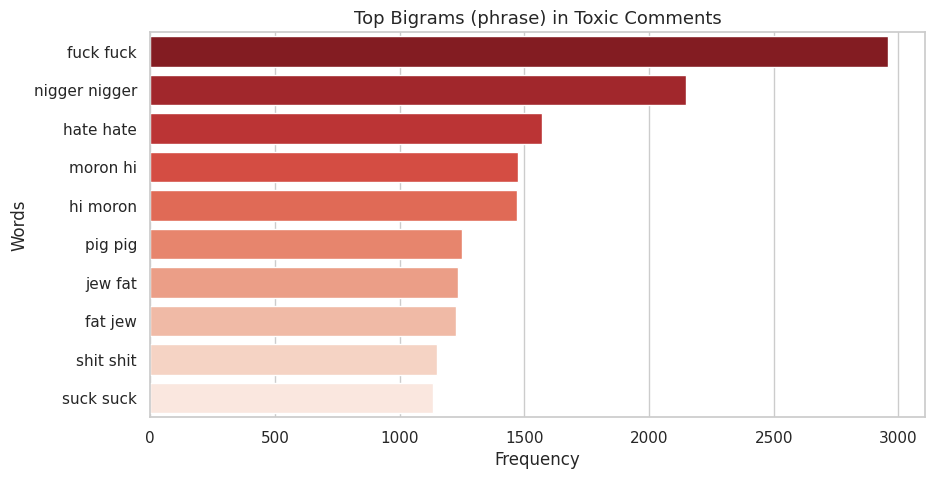

In [ ]:
from numpy import vecdot
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

def get_top_ngrams (corpus, title, ngram_range=(1,1), top_n=10):
  vec = CountVectorizer(ngram_range=ngram_range, stop_words='english', max_features=1000).fit(corpus)
  bag_of_words = vec.transform(corpus)
  sum_words = bag_of_words.sum(axis=0)
  words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
  words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

  top_n_ngrams = words_freq[:top_n]
  words = [word for word, freq in top_n_ngrams]
  freq = [freq for word, freq in top_n_ngrams]

  plt.figure(figsize=(10, 5))
  sns.barplot(
    x=list(freq),
    y=list(words),
    hue=list(words),
    palette='Reds_r',
    legend=False
  )
  plt.title(title, fontsize=13)
  plt.xlabel('Frequency', fontsize=12)
  plt.ylabel('Words', fontsize=12)
  plt.show()

toxic_comments = train_df[train_df['any_toxic'] == 1]['comment_text'].dropna()

get_top_ngrams(toxic_comments, 'Top Unigrams(single word) in Toxic Comments', ngram_range=(1,1), top_n=10)
get_top_ngrams(toxic_comments, 'Top Bigrams (phrase) in Toxic Comments', ngram_range=(2,2), top_n=10)

# PreProcessing

**Raw data from the trained dataset before any
pre processing **

In [ ]:
train_df[['comment_text', "toxic"]].sample(6)

,comment_text,toxic
32930,"""\nWhile you and perhaps others will want to s...",0
74227,August 2012 (UTC)\nSupport rename to Ashton Ku...,0
75292,"Yeah, none of the content you added meets any ...",0
116066,Last warning \n\nPlease stop. If you continue ...,0
140813,"""\nI disagree. The point of asking the wider c...",0
39961,"""\nFurthermore, are you saying you spent """"hou...",0


**Basic Preprocessing**



1.   Lower case




In [ ]:
def to_lower(text):
    return text.lower()


2.   URL remove



In [ ]:
def remove_urls(text):
    import re
    return re.sub(r"http\S+|www\S+", "", text)


3. Mentions remove



In [ ]:
def remove_mentions(text):
    import re
    return re.sub(r"@\w+", "", text)



4. Remove Punctuation



In [ ]:
def remove_punctuation(text):
    import re
    return re.sub(r"[^a-zA-Z\s]", "", text)


5. Remove extra space




In [ ]:
def remove_extra_spaces(text):
    import re
    return re.sub(r"\s+", " ", text).strip()

<!-- 6. Stopword removed -->

In [ ]:
# def stopword_removal(text):
#     stopwords = {"the", "is", "a", "an"}
#     return " ".join([w for w in text.split() if w not in stopwords])

**Advance Preprocessing**

In [ ]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 15.7 MB/s eta 0:00:00


1. Emoji to text

In [ ]:
import emoji

def emoji_to_text(text):
  return emoji.demojize(text, delimiters=(" ", " "))

 2. Convert to full forms



In [ ]:
# def expand_contractions(text):
#   contractions = {
#     "ain't": "is not",
#     "aren't": "are not",
#     "can't": "cannot",
#     "can't've": "cannot have",
#     "'cause": "because",
#     "don't": "do not",
#     "you're": "you are",
#     "it's": "it is",
#     "i'm": "i am",
#     "won't": "will not"
#   }
#   for k,v in contractions.items():
#       text = text.replace(k,v)
#       return text



In [ ]:
def expand_contractions(text):
    contractions = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "can't've": "cannot have",
        "'cause": "because",
        "don't": "do not",
        "you're": "you are",
        "it's": "it is",
        "i'm": "i am",
        "won't": "will not"
    }

    for k, v in contractions.items():
        text = text.replace(k, v)

    return text

3. Normalize repetitions\
stuuuuupid → stupid

In [ ]:
def normalize_repeated_chars(text):
    return re.sub(r"(.)\1{2,}", r"\1\1", text)

4. Bad Word Normalization\
b!tch = bitch

In [ ]:
def normalize_obscene(text):
    text = text.replace("b!tch", "bitch")
    text = text.replace("f*ck", "fuck")
    text = text.replace("a$$", "ass")
    return text

5. Tokenization

In [ ]:
from nltk.tokenize import word_tokenize
from tensorflow.keras.preprocessing.text import Tokenizer

In [ ]:
# sample_text = train_df['comment_text'].iloc[0]

# clean_text = advanced_preprocess(sample_text)
# tokens = word_tokenize(clean_text)
def tokenize_text(text):
    return word_tokenize(text)

In [ ]:
# print("Original text:", sample_text)
# print("Clean text:", clean_text)
# print("Tokens:", tokens)

Stopwords

In [ ]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
# stop_words = set(stopwords.words('english'))
# stopwords=True
# if stopwords:
#         tokens = [t for t in tokens if t not in stop_words]
#         print("Tokens after removing stop words:", tokens)

stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words]


Lemmatize

In [ ]:
# lemmatizer = WordNetLemmatizer()
# lemmatize=True
# if lemmatize:
#         tokens = [lemmatizer.lemmatize(t) for t in tokens]
#         print('tokens after Lammatization: ', tokens)

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]

PreProcess function

In [ ]:
def basic_preprocess(text):
    text = to_lower(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = remove_punctuation(text)
    text = remove_extra_spaces(text)
    return text

In [ ]:
# def advanced_preprocess(text,remove_sw=True,lemmatize=True):
#     text = emoji_to_text(text)
#     text = expand_contractions(text)
#     text = normalize_obscene(text)
#     text = normalize_repeated_chars(text)
#     text = to_lower(text)
#     text = remove_urls(text)
#     text = remove_mentions(text)
#     text = remove_punctuation(text)
#     text = remove_extra_spaces(text)
#     tokens = tokenize_text(text)
#     if lemmatize:
#         tokens = lemmatize_tokens(tokens)
#     return text

In [ ]:
def advanced_preprocess(text, remove_sw=True, lemmatize=True):
    text = emoji_to_text(text)
    text = expand_contractions(text)
    text = normalize_obscene(text)
    text = normalize_repeated_chars(text)

    text = to_lower(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = remove_punctuation(text)
    text = remove_extra_spaces(text)

    tokens = tokenize_text(text)

    if remove_sw:
        tokens = remove_stopwords(tokens)

    if lemmatize:
        tokens = lemmatize_tokens(tokens)

    return " ".join(tokens)

# Apply the preprocessing

Before Applying

In [ ]:
pd.set_option('display.max_colwidth', None)
train_df["raw"] = train_df["comment_text"]
train_df[["raw"]].sample(5)


,raw
45714,"""\n Haha. I knew it. Good job chickening out Psycho. Really shows your character. chat """
25402,You are probably right about AM Wood. Did you check the other XIs - I piped them mostly by (educated) guess-work. → (talk • contribs)
134759,"Look, what's your problem, kid? Have you got some kind of disorder, or something like that? This is the part I need to put in, OK:\n\nThe band toured Britain in the winter of 1974, taking a quadraphonic sound system and a fabulous light show on the road. They performed the Dark Side of the Moon, and high lights from their forthcoming album.\n\nSo just get on with it... unless you have some kind of power problem,. What is it with you, anyway. Can't we edit your stuff?"
43266,"""Does it mean that, for example, a story of Jesus Christ is a pseudoscientific hypothesis ? Because, according to the above, it is A hypothesis that """"lacks supporting scientific evidence or plausibility, cannot be reliably tested, or otherwise lacks scientific status""""...\n\n"""
346,"Okay, I'll give it another whirl via email. If worst comes to worst, i.e. if I do not get a reply soon, than I can always just use new accounts if I am ignored and that way it will just keep those who have been stalking me tied down/busy chasing me around rather than trying to delete content. Take care!"


Applying Basic Preprocessing

In [ ]:

train_df["basic_clean"] = train_df["raw"].apply(basic_preprocess)
train_df[["basic_clean"]].sample(5)

basic_clean
61864                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

Comparison Of Raw and Basic Clean by Basic Preprocessing

In [ ]:
pd.set_option('display.max_colwidth', None)
train_df[["raw", "basic_clean"]].sample(5)

,raw,basic_clean
64467,"""Nope...same crashing persists. — (Talk) \n\n""",nopesame crashing persists talk
64555,8 July 2005 22:39 (UTC),july utc
137556,"""\n\n Please do not vandalize pages, as you did with this edit to Dick (film). If you continue to do so, you will be blocked from editing. """,please do not vandalize pages as you did with this edit to dick film if you continue to do so you will be blocked from editing
81331,R U aware\n\nI read everything you post?\n\nbeckjord,r u aware i read everything you post beckjord
108908,"Jeff G is a faggot, as well as J Delanoy. They suck on each others cocks and gurgle their AIDS infected semen passionately, while being smug, nigger loving liberal jewbags.",jeff g is a faggot as well as j delanoy they suck on each others cocks and gurgle their aids infected semen passionately while being smug nigger loving liberal jewbags


Applying Advanced Preprocessing

In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
train_df["advanced_clean"] = train_df["raw"].apply(advanced_preprocess)
train_df[["advanced_clean"]].sample(5)

,advanced_clean
157454,abuse response filing greeting thank filing abuse report abusive behavior originating
65941,sign comment please moving identified sock dewan user kww fence window please block user
99909,gwen factual accuracy mostly implies majority case besides openfutureboy whatever fuck called behaving like dick getting uppity someone call pretty pathetic see wolfowitz well he getting people nose since dawn time youll note numerical majority edits minor constructive ill continue path youd prefer unblock keep blocked hugely important stop making little edits prefer occasionally insulting dick like openlegboy someone need call
64451,iirc heard dr demento give full name band ogden edsl rotorooter goodtime christmas band
73613,deletion nomination thanks supporting john pinnigers article could look dr mark mayalls article also nominator proposing others deletion one wonder great must modest bio wikipedia thanks


Comparison of Raw and Advanced Clean by Advanced Preprocessing


In [ ]:
pd.set_option('display.max_colwidth', None)
train_df[["raw","advanced_clean"]].sample(5)

,raw,advanced_clean
66038,"Ok, you are unblocked. \n\nPlease read WP:C. In general, we can't use anything that has been previously published unless it is very old. If you have any copyright questions ask me, or leave a note at Wikipedia_talk:Copyright_problems. Duk",ok unblocked please read wpc general use anything previously published unless old copyright question ask leave note wikipediatalkcopyrightproblems duk
49863,"""\n""""Wikipedia is not a court-hearing transcript"""". Well this directly contradicts Wikipedia policy itself where when reputable sources contradict one another, then you are required to present the differing viewpoints with clarity. If this turns out to be like a 'court-hearing transcript' transcript so be it (but you are misunderstanding my use of 'he says'. We don't need to specifically do that if the context makes it clear anyway:\nNPOV weights viewpoints in proportion to their prominence. However, when reputable sources contradict one another and are relatively equal in prominence, the core of the NPOV policy is to let competing approaches exist on the same page: work for balance, that is: describe the opposing viewpoints according to reputability of the sources, and give precedence to those sources that are most reliable and verifiable. \nI have a suggestion. I'll write the Ernst and al viewpoint and you do the other. I can do mine first. """,wikipedia courthearing transcript well directly contradicts wikipedia policy reputable source contradict one another required present differing viewpoint clarity turn like courthearing transcript transcript misunderstanding use say need specifically context make clear anyway npov weight viewpoint proportion prominence however reputable source contradict one another relatively equal prominence core npov policy let competing approach exist page work balance describe opposing viewpoint according reputability source give precedence source reliable verifiable suggestion ill write ernst al viewpoint mine first
8738,"Ways to improve Level 6 syndrome \n\nHi, I'm Chris Mason. Gabriel esthers, thanks for creating Level 6 syndrome!\n\nI've just tagged the page, using our page curation tools, as having some issues to fix. I'd take a look at articles of other medical conditions and see if you can use them as examples in developing this article. Specifically in adding some good references that will help others develop this as well.\n\nThe tags can be removed by you or another editor once the issues they mention are addressed. If you have questions, you can leave a comment on my talk page. Or, for more editing help, talk to the volunteers at the Teahouse.",way improve level syndrome hi im chris mason gabriel esther thanks creating level syndrome ive tagged page using page curation tool issue fix id take look article medical condition see use example developing article specifically adding good reference help others develop well tag removed another editor issue mention addressed question leave comment talk page editing help talk volunteer teahouse
122209,"Previous routes served by airlines \n\nAer Arann (Nantes)\nAer Lingus (Prague, Rennes)\nCentral Wings (Warsaw)\nRyanair (Glasgow-Prestwick, East Midlands)",previous route served airline aer arann nantes aer lingus prague rennes central wing warsaw ryanair glasgowprestwick east midland
99772,"I can totally appreciate that the Facebook page isn't considered a reliable resource since it is from one side of the story.\nSo I have no problem with your stance on this.\n\nAgain, as I have stated many times, I am only a merely a scholar of well-known criminal case. Several of which, are listed in Wikipedia. Oddly, the Sante Kimes page is the one that I saw had lots of incorrect information listed on it. I agree that my first edits weren't the correct way to improve the quality of the page, but I have since tried to follow the correct procedure and post here and add tags for larger amounts of questionable information.\n\nI think the quali

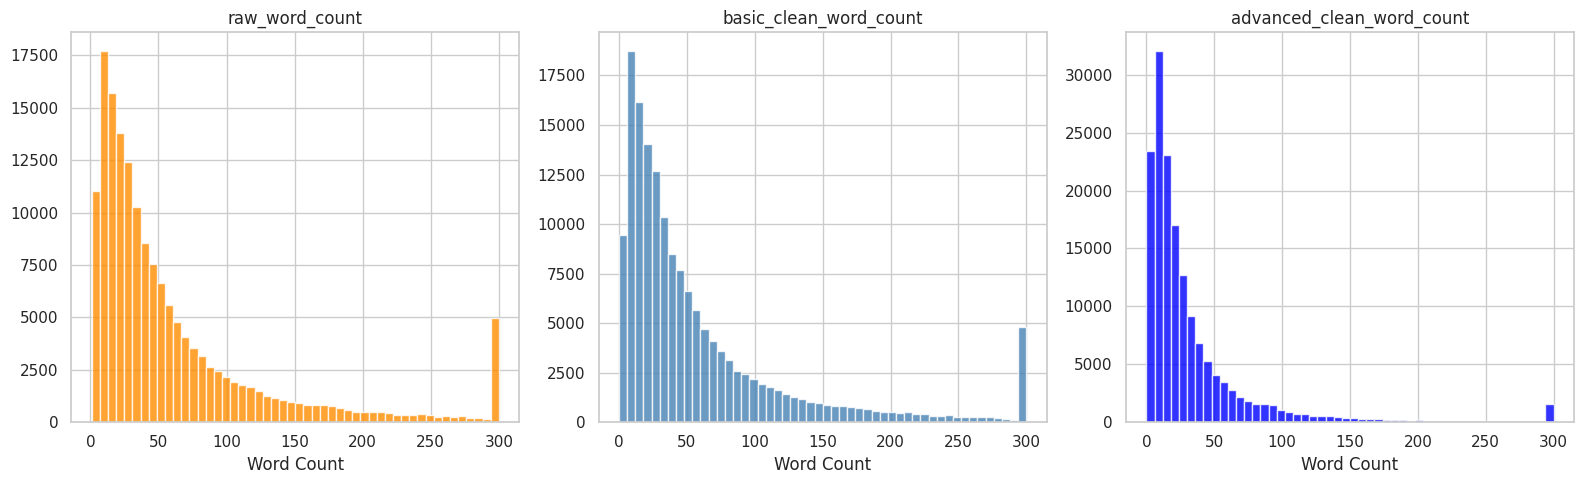

In [ ]:
train_df['raw_word_count'] =train_df['comment_text'].str.split().str.len()
train_df['basic_clean_word_count'] =train_df['basic_clean'].str.split().str.len()
train_df['advanced_clean_word_count'] =train_df['advanced_clean'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(16,5))
axes[0].hist(train_df['raw_word_count'].clip(upper=300),bins=50,color="darkorange", edgecolor='white',alpha=0.8)
axes[0].set_title('raw_word_count' , fontsize=12)
axes[0].set_xlabel('Word Count')


axes[1].hist(train_df['basic_clean_word_count'].clip(upper=300),bins=50,color="steelblue", edgecolor='white',alpha=0.8)
axes[1].set_title('basic_clean_word_count' , fontsize=12)
axes[1].set_xlabel('Word Count')


axes[2].hist(train_df['advanced_clean_word_count'].clip(upper=300),bins=50,color="blue", edgecolor='white',alpha=0.8)
axes[2].set_title('advanced_clean_word_count' , fontsize=12)
axes[2].set_xlabel('Word Count')

plt.tight_layout()
plt.savefig('word_count_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
print('Raw text stats:')    ; print(train_df['raw_word_count'].describe().round(1))
print('\n basic Cleaned text stats:'); print(train_df['basic_clean_word_count'].describe().round(1))
print('\n advance Cleaned text stats:'); print(train_df['advanced_clean_word_count'].describe().round(1))


Raw text stats:
count    159571.0
mean         67.3
std          99.2
min           1.0
25%          17.0
50%          36.0
75%          75.0
max        1411.0
Name: raw_word_count, dtype: float64

 basic Cleaned text stats:
count    159571.0
mean         65.4
std          97.3
min           0.0
25%          16.0
50%          35.0
75%          73.0
max        1403.0
Name: basic_clean_word_count, dtype: float64

 advance Cleaned text stats:
count    159571.0
mean         34.0
std          52.5
min           0.0
25%           8.0
50%          18.0
75%          37.0
max        1250.0
Name: advanced_clean_word_count, dtype: float64


In [ ]:
(train_df['basic_clean'] == train_df['advanced_clean']).sum()

np.int64(3383)

In [ ]:
for i in range(2):
    print("RAW:", train_df['comment_text'].iloc[i])
    print("BASIC:", train_df['basic_clean'].iloc[i])
    print("ADVANCED:", train_df['advanced_clean'].iloc[i])
    print("-"*50)

RAW: Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27
BASIC: explanation why the edits made under my username hardcore metallica fan were reverted they werent vandalisms just closure on some gas after i voted at new york dolls fac and please dont remove the template from the talk page since im retired now
ADVANCED: explanation edits made username hardcore metallica fan reverted werent vandalism closure gas voted new york doll fac please remove template talk page since im retired
--------------------------------------------------
RAW: D'aww! He matches this background colour I'm seemingly stuck with. Thanks.  (talk) 21:51, January 11, 2016 (UTC)
BASIC: daww he matches this background colour im seemingly stuck with thanks talk january utc
ADVANCED: daww match background colou

# Train  Validation  Test Split

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

In [ ]:
x = train_df[['raw','basic_clean','advanced_clean']]
y = train_df[label_counts.index]

X_train, X_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.2, random_state=RANDOM_SEED, stratify=train_df['any_toxic']
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED,
    stratify=y_temp.max(axis=1)
)

print(f'Train : {len(X_train):,}  |  Val : {len(X_val):,}  |  Test : {len(X_test):,}')

Train : 127,656  |  Val : 15,957  |  Test : 15,958


# Feature Extraction

1. TF_IDF (for LR and SVM) \
use advanced_clean

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [ ]:
tfidf = TfidfVectorizer(
    max_features=50000 ,
    ngram_range=(1,2),
    sublinear_tf=True,
    min_df =3
)
X_train_tfidf = tfidf.fit_transform(X_train['advanced_clean'])
X_val_tfidf = tfidf.transform(X_val['advanced_clean'])
X_test_tfidf = tfidf.transform(X_test['advanced_clean'])


In [ ]:
print('TD_IFD shape train', X_train_tfidf.shape)
print('TD_IFD shape val', X_val_tfidf.shape)
print('TD_IFD shape test', X_test_tfidf.shape)

TD_IFD shape train (127656, 50000)
TD_IFD shape val (15957, 50000)
TD_IFD shape test (15958, 50000)


2. Tokenization & Padding (for LSTM) \
basic_clean

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences # Import pad_sequences



In [ ]:
Vocab_size =20000
max_len= 100

lstm_tok = Tokenizer(num_words=Vocab_size, oov_token='<OOV>')
lstm_tok.fit_on_texts(X_train['basic_clean'])

def to_padded(texts):
  seqs = lstm_tok.texts_to_sequences(texts) # Corrected method name to texts_to_sequences
  return pad_sequences(seqs, maxlen=max_len, padding='post', truncating='post')
X_train_lstm = to_padded(X_train['basic_clean'])
X_val_lstm = to_padded(X_val['basic_clean'])
X_test_lstm = to_padded(X_test['basic_clean'])

In [ ]:
print('LSTM shape train', X_train_lstm.shape)
print('LSTM shape val', X_val_lstm.shape)
print('LSTM shape test', X_test_lstm.shape)

LSTM shape train (127656, 100)
LSTM shape val (15957, 100)
LSTM shape test (15958, 100)


3. BERT Tokenizer (for BERT) \
raw dataset

In [ ]:
from transformers import (BertTokenizer, BertForSequenceClassification,
                          get_linear_schedule_with_warmup)

In [ ]:
Bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
def bert_encode(texts, max_len=512):
   enc =bert_tokenizer(
       list(texts),
       max_length=max_len,
       truncation=True,
       padding = 'max_length',
       return_tensors='tf'
   )
   return enc['input_ids'], enc['attention_mask']

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# Evaluation toolkit
for comparing easily

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              classification_report, confusion_matrix)


In [ ]:
results ={}
def evaluate(model_name,y_true,y_pred, elapsed_train=None,elapsed_infer=None ):
  acc = accuracy_score(y_true, y_pred)
  prec = precision_score(y_true, y_pred, average='macro',zero_division=0)
  rec = recall_score(y_true, y_pred, average='macro',zero_division=0)
  f1 = f1_score(y_true, y_pred, average='macro',zero_division=0)

  results[model_name] = {
      'accuracy': round(acc,4),
      'precision': round(prec,4),
      'recall': round(rec,4),
      'f1 (macro)': round(f1,4),
      'train time (s)':round( elapsed_train,1) if elapsed_train else '-',
      'infer time (s)': round(elapsed_infer,1) if elapsed_infer else '-'
  }
  print(f'\n===== {model_name} =====')
  print(f'  accuracy : {acc:.4f}')
  print(f'  precision: {prec:.4f}')
  print(f'  recall   : {rec:.4f}')
  print(f'  f1 Macro : {f1:.4f}')
  if elapsed_train: print(f'  train time: {elapsed_train:.1f}s')
  return results[model_name]


In [ ]:
# from sklearn.metrics import (
#     accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score,
#     roc_auc_score
# )

# results = {}

# def evaluate(model_name, y_true, y_pred, y_prob=None,
#              elapsed_train=None, elapsed_infer=None):

#     acc = accuracy_score(y_true, y_pred)

#     prec = precision_score(
#         y_true, y_pred,
#         average='macro',
#         zero_division=0
#     )

#     rec = recall_score(
#         y_true, y_pred,
#         average='macro',
#         zero_division=0
#     )

#     macro_f1 = f1_score(
#         y_true, y_pred,
#         average='macro',
#         zero_division=0
#     )

#     weighted_f1 = f1_score(
#         y_true, y_pred,
#         average='weighted',
#         zero_division=0
#     )

#     # ROC-AUC
#     if y_prob is not None:
#         roc_auc = roc_auc_score(
#             y_true,
#             y_prob,
#             average='macro'
#         )
#     else:
#         roc_auc = None

#     results[model_name] = {
#         'accuracy': round(acc, 4),
#         'precision': round(prec, 4),
#         'recall': round(rec, 4),
#         'macro f1': round(macro_f1, 4),
#         'weighted f1': round(weighted_f1, 4),
#         'roc-auc': round(roc_auc, 4) if roc_auc else '-',
#         'train time (s)': round(elapsed_train, 1) if elapsed_train else '-',
#         'infer time (s)': round(elapsed_infer, 1) if elapsed_infer else '-'
#     }

#     print(f'\n===== {model_name} =====')
#     print(f'Accuracy     : {acc:.4f}')
#     print(f'Precision    : {prec:.4f}')
#     print(f'Recall       : {rec:.4f}')
#     print(f'Macro F1     : {macro_f1:.4f}')
#     print(f'Weighted F1  : {weighted_f1:.4f}')

#     if roc_auc is not None:
#         print(f'ROC-AUC      : {roc_auc:.4f}')

#     if elapsed_train:
#         print(f'Train time   : {elapsed_train:.1f}s')

#     return results[model_name]

In [ ]:
def plot_confusion(model_name,y_true, y_pred, labels, lables=label_cols):
   fig, axes = plt.subplots( 2,3, figsize=(15,8))
   for ax, col in zip(axes.flatten(), labels):
       cm = confusion_matrix(y_true[:, labels.index(col)],
                              y_pred[:, labels.index(col)])
       sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                    cmap='Blues', cbar=False)
       ax.set_title(col, fontsize=11)
       ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
   plt.suptitle(f'Confusion Matrices — {model_name}', fontsize=14)
   plt.tight_layout()
   plt.savefig(f'cm_{model_name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
   plt.show()

print('Evaluation helpers ready.')

Evaluation helpers ready.


# Model 1 — TF-IDF + Logistic Regression



## 1. Raw text version



In [ ]:
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.models import Model
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

In [ ]:
tfidf_raw = TfidfVectorizer(max_features=50000, ngram_range=(1,2),sublinear_tf=True, min_df=3)
X_train_tfidf_raw = tfidf_raw.fit_transform(X_train['raw'])
X_test_tfidf_raw = tfidf_raw.transform(X_test['raw'])

lr_raw = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_SEED))
t0 = time.time()
lr_raw.fit(X_train_tfidf_raw, y_train)
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')

t0=time.time()
y_pred_raw = lr_raw.predict(X_test_tfidf_raw)
infer_t= time.time() - t0


Train time: 23.4s


In [ ]:
sample_comments = [
    "I love your videos",
    "You are a stupid idiot",
    "Have a nice day",
    "Shut up moron",
    "Amazing work"
]

sample_clean = [basic_preprocess(t) for t in sample_comments]
sample_tfidf = tfidf_raw.transform(sample_clean)

probs = lr_raw.predict_proba(sample_tfidf)

threshold = 0.5

for text, prob in zip(sample_comments, probs):

    print("\nComment:", text)

    toxic_found = False

    for label, p in zip(label_cols, prob):

        if p > threshold:
            toxic_found = True
            print(f"{label}: {p:.2%}")

    if not toxic_found:
        print("Prediction: Non-toxic")


Comment: I love your videos
Prediction: Non-toxic

Comment: You are a stupid idiot
toxic: 100.00%
severe_toxic: 96.38%
obscene: 99.99%

Comment: Have a nice day
Prediction: Non-toxic

Comment: Shut up moron
toxic: 99.84%
severe_toxic: 82.45%
obscene: 96.65%

Comment: Amazing work
Prediction: Non-toxic


Evaluate the model for raw data

In [ ]:
evaluate('TF-IDF + LR (raw)', y_test.values, y_pred_raw, train_t, infer_t)


===== TF-IDF + LR (raw) =====
  accuracy : 0.9204
  precision: 0.8366
  recall   : 0.3936
  f1 Macro : 0.5099
  train time: 23.4s


{'accuracy': 0.9204,
 'precision': 0.8366,
 'recall': 0.3936,
 'f1 (macro)': 0.5099,
 'train time (s)': 23.4,
 'infer time (s)': 0.0}

In [ ]:
# y_prob_raw = lr_raw.predict_proba(X_test_tfidf_raw)

# evaluate(
#     'TF-IDF + LR (raw)',
#     y_test.values,
#     y_pred_raw,
#     y_prob=y_prob_raw,
#     elapsed_train=train_t,
#     elapsed_infer=infer_t
# )

Confusion plot for the model for raw data

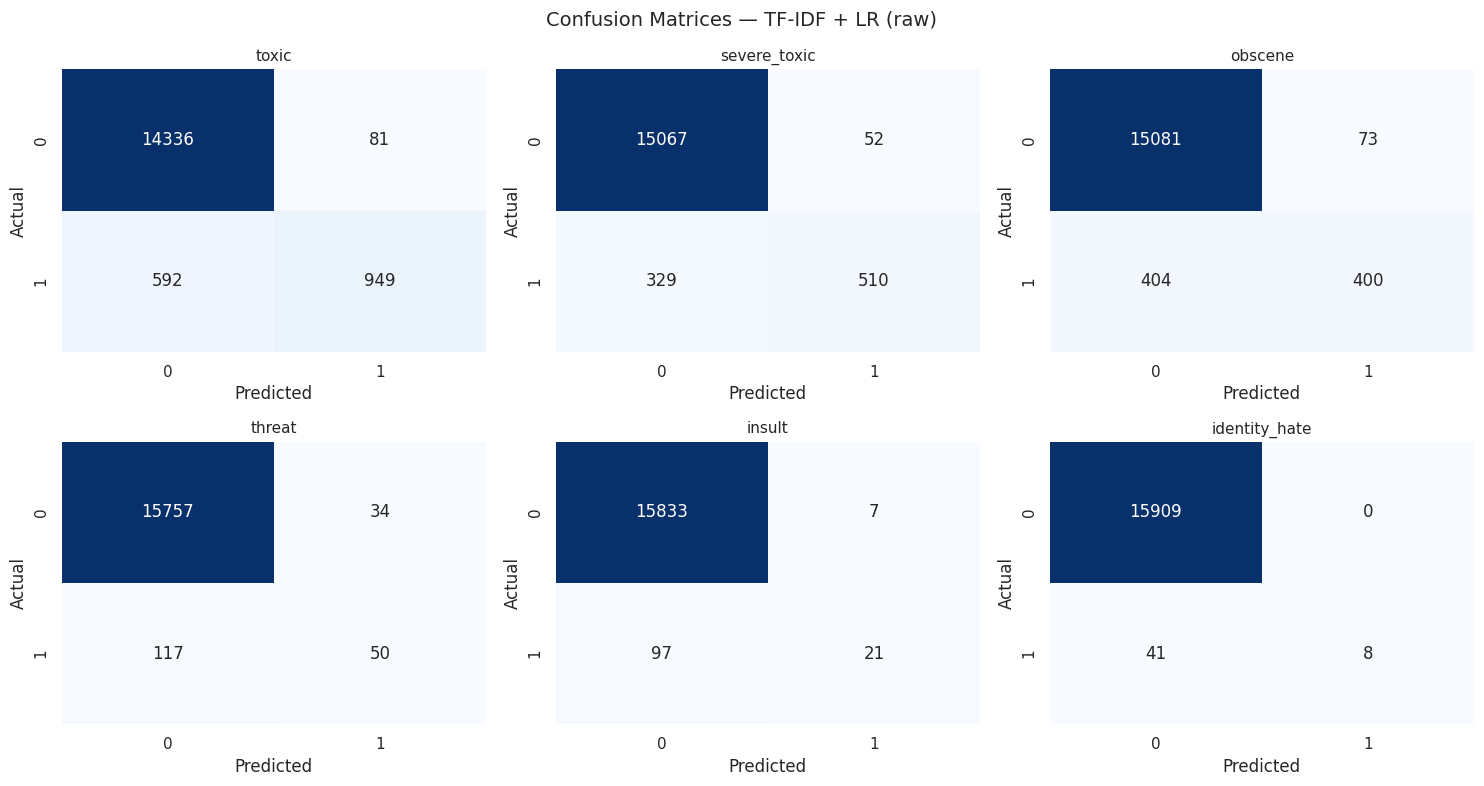

In [ ]:
plot_confusion('TF-IDF + LR (raw)', y_test.values, y_pred_raw, label_cols)

## 2. Advanced clean version

In [ ]:
tfidf_clean = TfidfVectorizer(max_features=50000, ngram_range=(1,2),sublinear_tf=True, min_df=3)
X_train_tfidf_clean = tfidf_clean.fit_transform(X_train['advanced_clean'])
X_test_tfidf_clean = tfidf_clean.transform(X_test['advanced_clean'])

lr_clean = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_SEED))
t0 = time.time()
lr_clean.fit(X_train_tfidf_clean, y_train)
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')

t0=time.time()
y_pred_clean = lr_clean.predict(X_test_tfidf_clean)
infer_t= time.time() - t0

Train time: 10.0s


In [ ]:
evaluate('TF-IDF + LR (advanced)', y_test.values, y_pred_clean, train_t, infer_t)


===== TF-IDF + LR (advanced) =====
  accuracy : 0.9189
  precision: 0.7585
  recall   : 0.3845
  f1 Macro : 0.4852
  train time: 10.0s


{'accuracy': 0.9189,
 'precision': 0.7585,
 'recall': 0.3845,
 'f1 (macro)': 0.4852,
 'train time (s)': 10.0,
 'infer time (s)': 0.0}

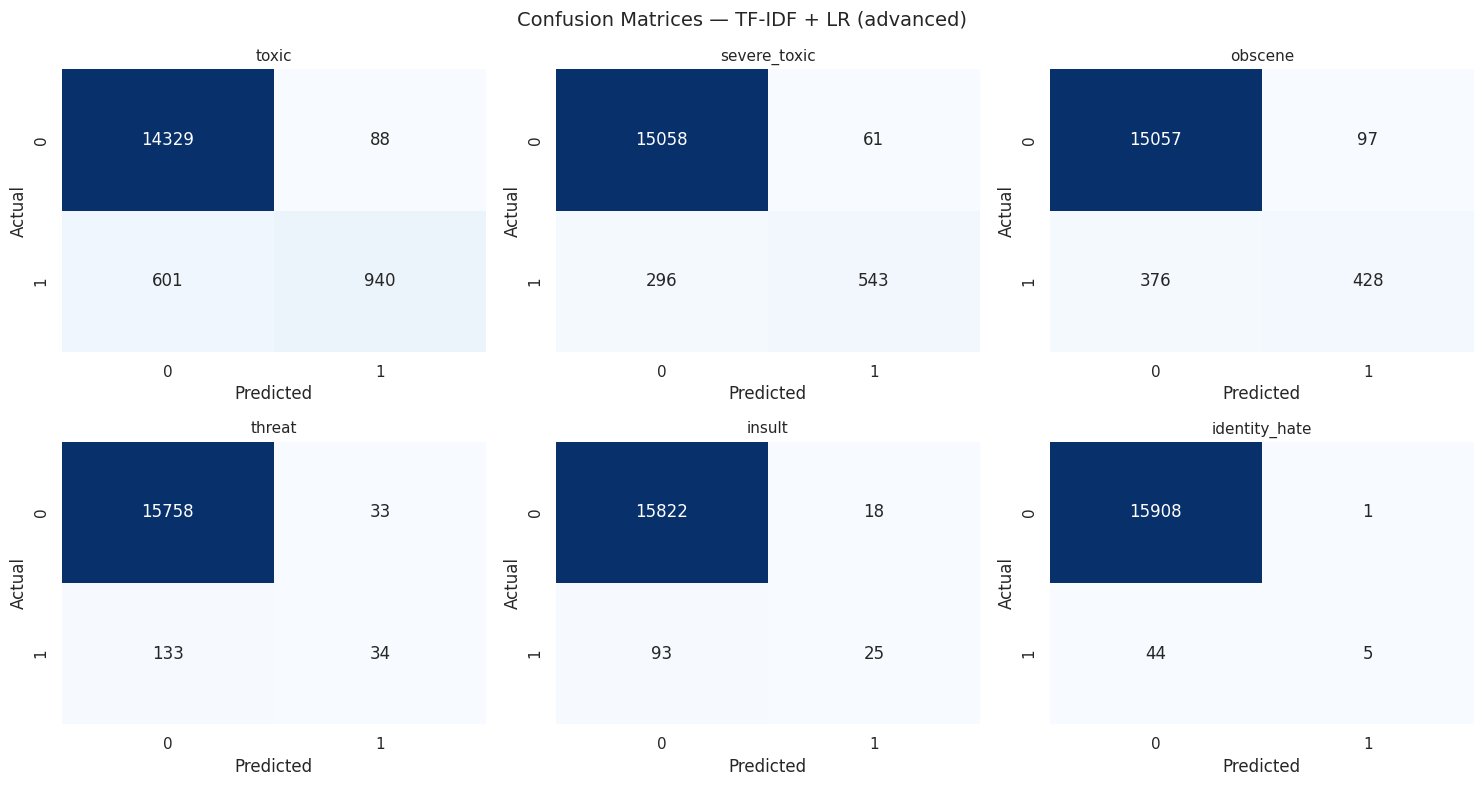

In [ ]:
plot_confusion('TF-IDF + LR (advanced)', y_test.values, y_pred_clean, label_cols)

The raw-text TF-IDF representation outperformed the advanced preprocessed version across all evaluation metrics. Excessive preprocessing may remove important contextual and emotional cues that contribute to toxicity identification.

In [ ]:
sample_comments = [
    "I love your videos",
    "You are a stupid idiot",
    "Have a nice day",
    "Shut up moron",
    "Amazing work"
]

sample_clean = [advanced_preprocess(t) for t in sample_comments]
sample_tfidf = tfidf_clean.transform(sample_clean)

probs = lr_clean.predict_proba(sample_tfidf)

threshold = 0.5

for text, prob in zip(sample_comments, probs):

    print("\nComment:", text)

    toxic_found = False

    for label, p in zip(label_cols, prob):

        if p > threshold:
            toxic_found = True
            print(f"{label}: {p:.2%}")

    if not toxic_found:
        print("Prediction: Non-toxic")


Comment: I love your videos
Prediction: Non-toxic

Comment: You are a stupid idiot
toxic: 100.00%
severe_toxic: 98.77%
obscene: 100.00%

Comment: Have a nice day
Prediction: Non-toxic

Comment: Shut up moron
toxic: 99.96%
severe_toxic: 89.89%
obscene: 98.20%

Comment: Amazing work
Prediction: Non-toxic


# **Model 2 — TF-IDF + SVM (LinearSVC)**

**Raw version **

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier

In [ ]:
svm_raw = OneVsRestClassifier(LinearSVC(max_iter=2000, C=1.0, random_state=RANDOM_SEED))

t0= time.time()
svm_raw.fit(X_train_tfidf_raw, y_train)
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')

t0=time.time()
y_pred_svm_raw = svm_raw.predict(X_test_tfidf_raw)
infer_t= time.time() - t0

Train time: 19.0s


In [ ]:
evaluate('TF-IDF + SVM (raw)', y_test.values, y_pred_svm_raw, train_t, infer_t)


===== TF-IDF + SVM (raw) =====
  accuracy : 0.9209
  precision: 0.7476
  recall   : 0.5065
  f1 Macro : 0.5944
  train time: 19.0s


{'accuracy': 0.9209,
 'precision': 0.7476,
 'recall': 0.5065,
 'f1 (macro)': 0.5944,
 'train time (s)': 19.0,
 'infer time (s)': 0.0}

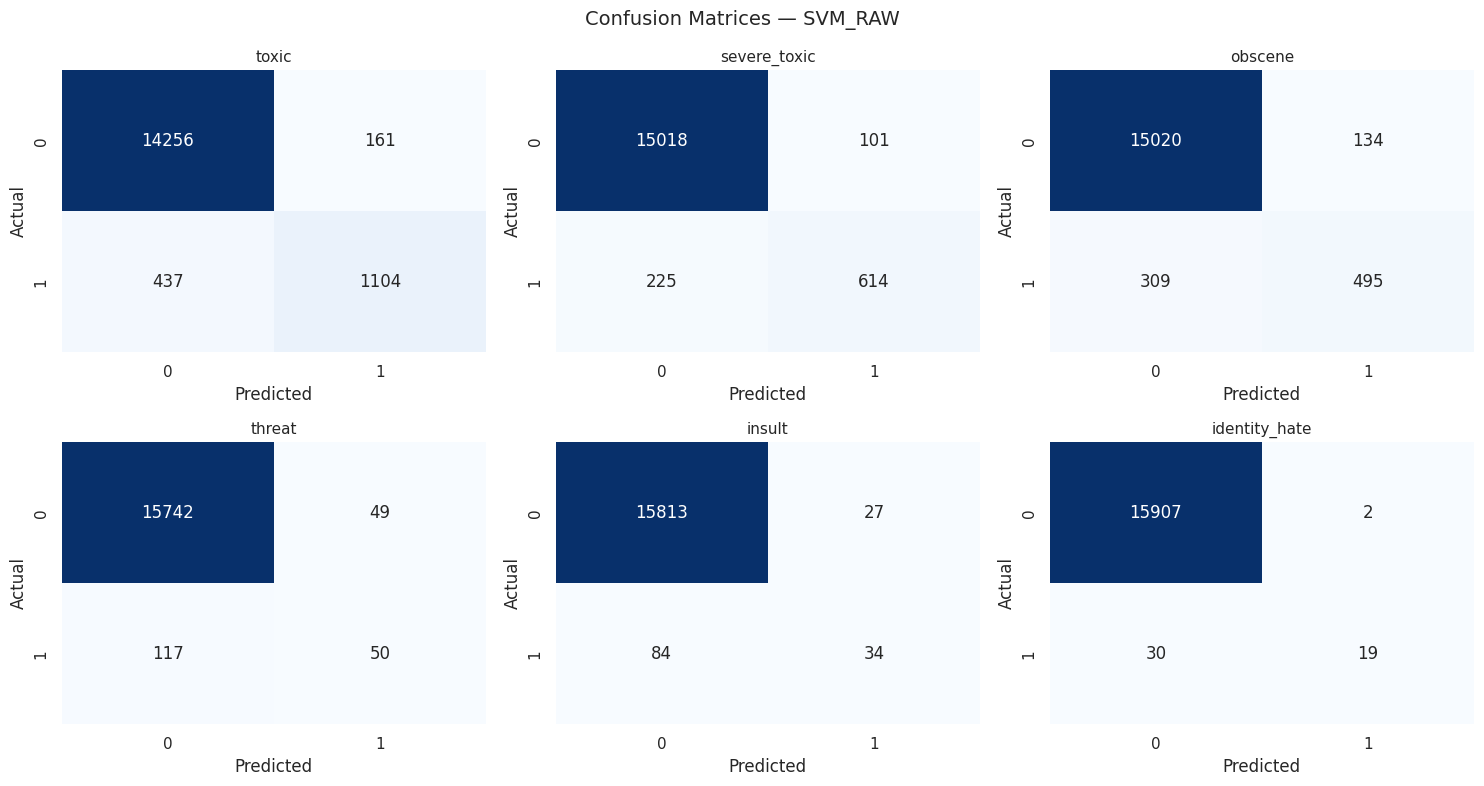

In [ ]:
plot_confusion('SVM_RAW',y_test.values,y_pred_svm_raw,label_cols)

In [ ]:
sample_comments = [
    "I love your videos",
    "You are a stupid idiot",
    "Have a nice day",
    "Shut up moron",
    "Amazing work"
]

sample_clean = [basic_preprocess(t) for t in sample_comments]
sample_tfidf = tfidf_raw.transform(sample_clean)
sample_pred = svm_raw.predict(sample_tfidf)

for text, pred in zip(sample_comments, sample_pred):

    print("\nComment:", text)

    toxic_found = False

    for label, value in zip(label_cols, pred):

        if value == 1:
            toxic_found = True
            print(f"{label}: Toxic")

    if not toxic_found:
        print("Prediction: Non-toxic")


Comment: I love your videos
Prediction: Non-toxic

Comment: You are a stupid idiot
toxic: Toxic
severe_toxic: Toxic
obscene: Toxic

Comment: Have a nice day
Prediction: Non-toxic

Comment: Shut up moron
toxic: Toxic
severe_toxic: Toxic
obscene: Toxic

Comment: Amazing work
Prediction: Non-toxic


**Advanced clean version**

In [ ]:
svm_clean= OneVsRestClassifier(LinearSVC(max_iter=2000, C=1.0, random_state=RANDOM_SEED))

t0= time.time()
svm_clean.fit(X_train_tfidf_clean, y_train)
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')

t0=time.time()
y_pred_svm_clean = svm_clean.predict(X_test_tfidf_clean)
infer_t= time.time() - t0

Train time: 6.5s


In [ ]:
evaluate('TF-IDF + SVM (advanced)', y_test.values, y_pred_svm_clean, train_t, infer_t)


===== TF-IDF + SVM (advanced) =====
  accuracy : 0.9187
  precision: 0.7193
  recall   : 0.4957
  f1 Macro : 0.5780
  train time: 6.5s


{'accuracy': 0.9187,
 'precision': 0.7193,
 'recall': 0.4957,
 'f1 (macro)': 0.578,
 'train time (s)': 6.5,
 'infer time (s)': 0.0}

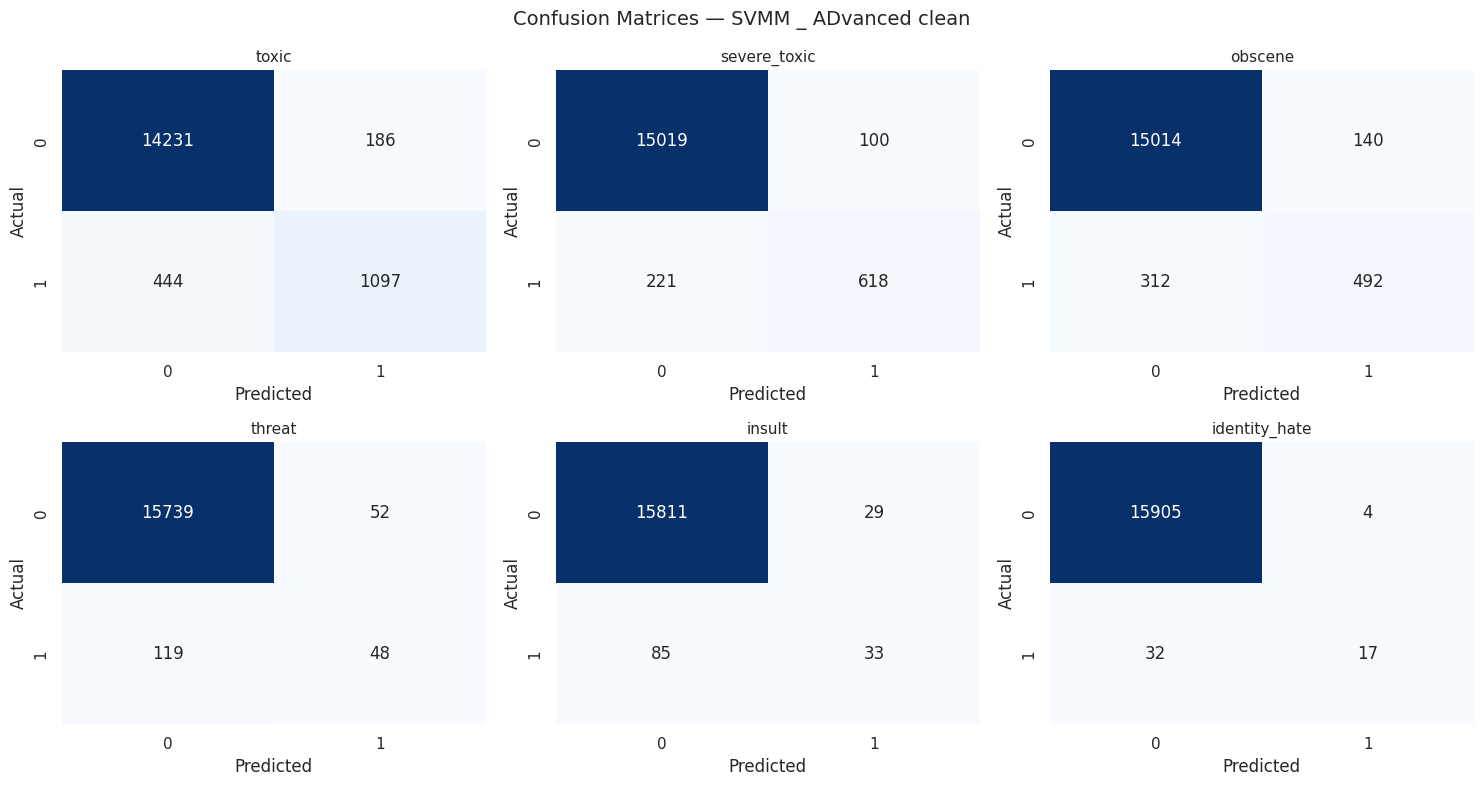

In [ ]:
plot_confusion("SVMM _ ADvanced clean", y_test.values, y_pred_svm_clean, label_cols)

In [ ]:
sample_comments = [
    "I love your videos",
    "You are a stupid idiot",
    "Have a nice day",
    "Shut up moron",
    "Amazing work"
]

# preprocess
sample_clean = [advanced_preprocess(t) for t in sample_comments]

# tfidf transform
sample_tfidf = tfidf_raw.transform(sample_clean)

# prediction
sample_pred = svm_raw.predict(sample_tfidf)

for text, pred in zip(sample_comments, sample_pred):

    print("\nComment:", text)

    toxic_found = False

    for label, value in zip(label_cols, pred):

        if value == 1:
            toxic_found = True
            print(f"{label}: Toxic")

    if not toxic_found:
        print("Prediction: Non-toxic")


Comment: I love your videos
Prediction: Non-toxic

Comment: You are a stupid idiot
toxic: Toxic
severe_toxic: Toxic
obscene: Toxic

Comment: Have a nice day
Prediction: Non-toxic

Comment: Shut up moron
toxic: Toxic
severe_toxic: Toxic
obscene: Toxic

Comment: Amazing work
Prediction: Non-toxic


# Model 3 — Bidirectional LSTM

In [ ]:
from tensorflow.keras.layers import (Input, Embedding, LSTM, Dense,
                                      Dropout, Bidirectional, GlobalMaxPooling1D)


Building the model



In [ ]:
EMBED_DIM = 128
NUM_LABELS = len(label_cols)

def build_bilstm(Vocab_size, max_len, num_labels):
    inp  = Input(shape=(max_len,))
    x    = Embedding(Vocab_size, EMBED_DIM)(inp)
    x    = Bidirectional(LSTM(64, return_sequences=True, dropout=0.2))(x)
    x    = GlobalMaxPooling1D()(x)
    x    = Dense(128, activation='relu')(x)
    x    = Dropout(0.3)(x)
    out  = Dense(num_labels, activation='sigmoid')(x)
    model = Model(inp, out)
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
lstm_model = build_bilstm(Vocab_size , max_len, NUM_LABELS)
lstm_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 100, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,676,102 (10.21 MB)

 Trainable params: 2,676,102 (10.21 MB)

 Non-trainable params: 0 (0.00 B)

Training the modle

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Model




In [ ]:
callbacks =[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, verbose=1)
            ]
t0=time.time()
history = lstm_model.fit(
    X_train_lstm, y_train.values,
    validation_data=(X_test_lstm, y_test.values),
    epochs=10,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)
train_t = time.time() - t0

print(f'Train time: {train_t:.1f}s')

Epoch 1/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.8595 - loss: 0.0798 - val_accuracy: 0.9949 - val_loss: 0.0496 - learning_rate: 0.0010
Epoch 2/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.9583 - loss: 0.0469 - val_accuracy: 0.9949 - val_loss: 0.0489 - learning_rate: 0.0010
Epoch 3/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.9364 - loss: 0.0419 - val_accuracy: 0.9949 - val_loss: 0.0503 - learning_rate: 0.0010
Epoch 4/10
996/998 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9031 - loss: 0.0387
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
998/998 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.8640 - loss: 0.0374 - val_accuracy: 0.9949 - val_loss: 0.0532 - learning_rate: 0.0010
Epoch 5/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.7960 - loss: 0.0319 - val_accuracy: 0.9914 - val_loss: 0.0570 - learning_rate: 5.0000e-04
Train time: 92.4s


Plot training curves

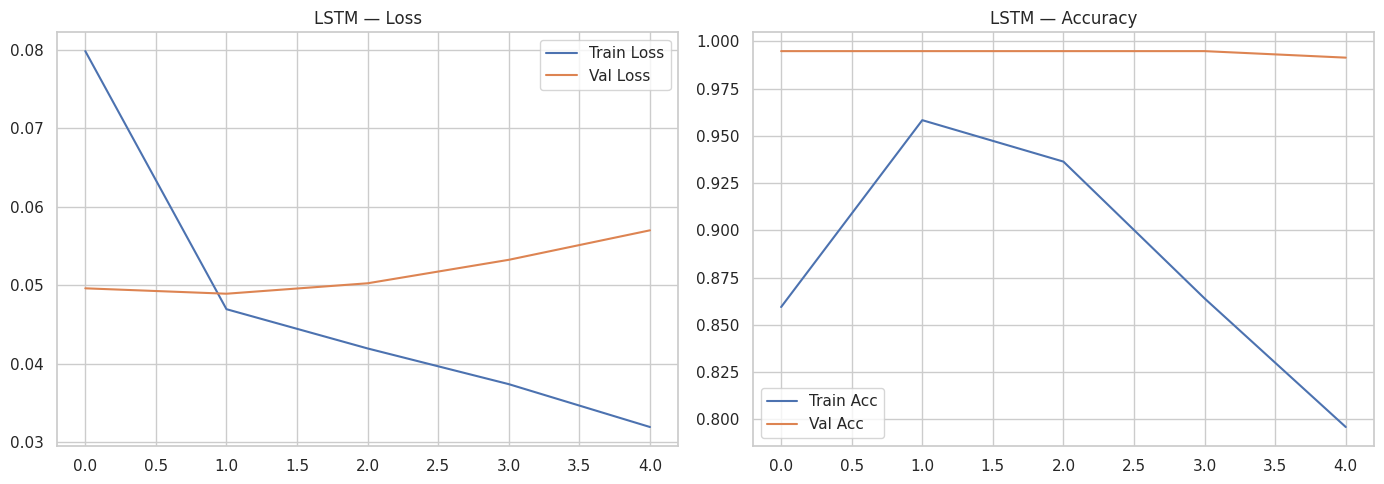

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('LSTM — Loss'); axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('LSTM — Accuracy'); axes[1].legend()

plt.tight_layout()
plt.savefig('lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()